# Twitter Hate Speech Classification — Fine-tuning Mistral-7B with QLoRA
### **Motivation**
With the increasing integration of AI systems into social media platforms, including conversational agents such as Grok, automated content moderation has become both more feasible and more consequential. Large language models are now embedded within online ecosystems where they can assist in identifying harmful or divisive content at scale.

This raises an important research question:

***Can fine-tuned LLMs reliably distinguish between hate speech and general offensive language in a way that supports safer online communities without over-censoring benign expression?***

Investigating this question is particularly relevant because the boundary between hate speech and offensive language is often ambiguous even for everyday social media users. Therefore, evaluating whether fine-tuning improves the model’s ability to make this nuanced distinction is particularly meaningful to me as it provides both technical insight and societal relevance.

The primary goal of this project is to investigate how an open-weight Large Language Model (LLM), specifically Mistral-7B, fine-tuned on explicitly labeled human social media data, can distinguish between nuanced forms of harmful content. This in particular, is hate speech versus offensive language and how this compares to the performance of the base model prior to fine-tuning.

### **Overview**
**Task:** 3-class Twitter tweet classification: `0` hate speech, `1` offensive language, `2` neither  
**Method:** QLoRA (4-bit NF4 quantization + LoRA adapters)  
**Hardware:** NVIDIA RTX 3090 (24GB), CUDA 11.7, PyTorch 2.0.1

This notebook documents the complete fine-tuning workflow for the selected task, including data loading, preprocessing, model configuration, training, checkpoint saving, evaluation, and analysis. 

This notebook is organised as follows:

1. **Environment Setup**  
2. **Imports**  
3. **Configuration**  
4. **Dataset Visualisation & Class Distribution Figures**  
5. **Train / Validation / Test Split**  
6. **Computation of Class Weights**  
7. **Prompt Formatting for LLM Input**  
8. **Loading Tokenizer & 4-bit Quantized Model**  
9. **Helper Utilities** (LoRA Builder, Parameter Counter, Loss Tracker)  
10. **Hyperparameter Search** (5 Configurations, 1 Epoch Each)  
11. **Full Training with Class-Weighted Loss**  
12. **Training Curve Visualisation**  
13. **Basic Inference Demonstration**  
14. **Base vs Fine-Tuned Evaluation** (100-Sample Evaluation Set)  
15. **Results & Performance Visualisation**  
16. **Full Test Set Evaluation Report**  
17. **Qualitative Error Analysis**  
18. **Discussion, Analysis & Ethical Risk Considerations**  
19. **Reproducibility & Source Citations**


Explanatory notes are included throughout to clarify key design choices and highlight configurable parameters for future experimentation.

**Disclaimer:** The dataset used contains ***harsh, offensive, and potentially disturbing language, including hate speech.*** The content is used solely for research and model training purposes. Reader discretion is advised.


## 1. Environment Setup

Install the required packages using the command below.  
Run this cell **once**, then restart the kernel (**Kernel → Restart Kernel**) before proceeding from Cell 2.

The configuration and dependency versions in this notebook were tested on the **SMU GPU Cluster** using an NVIDIA RTX 3090 (24GB VRAM).

In [1]:
import sys

# All versions confirmed working: PyTorch 2.0.1+cu117, CUDA 11.7
!{sys.executable} -m pip install transformers==4.40.0  --no-cache-dir -q
!{sys.executable} -m pip install datasets==2.19.0      --no-cache-dir -q
!{sys.executable} -m pip install peft==0.10.0          --no-cache-dir -q
!{sys.executable} -m pip install trl==0.8.6            --no-cache-dir -q
!{sys.executable} -m pip install bitsandbytes==0.41.3  --no-cache-dir -q
!{sys.executable} -m pip install accelerate==0.29.3    --no-cache-dir -q
!{sys.executable} -m pip install setuptools            --no-cache-dir -q
!{sys.executable} -m pip install "numpy<2"             --no-cache-dir -q
!{sys.executable} -m pip install triton==2.0.0         --no-cache-dir -q
!{sys.executable} -m pip install scipy scikit-learn matplotlib seaborn pandas -q

print("Done! Kernel -> Restart Kernel, then run from Cell 2 onwards.")

Done! Kernel -> Restart Kernel, then run from Cell 2 onwards.


## 2. Imports

In [ ]:
import os

# Must be set before importing bitsandbytes
os.environ["BNB_CUDA_VERSION"]     = "117"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import gc
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    TrainerCallback,
)
from transformers.modeling_utils import ModuleUtilsMixin
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)
from trl import SFTTrainer
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# ── Code for handling floating_point_ops incompatibility between
# ── transformers==4.40.0 and bitsandbytes==0.41.3
_orig_num_parameters = ModuleUtilsMixin.num_parameters
def _patched_num_parameters(self, only_trainable=False, exclude_embeddings=False):
    try:
        return _orig_num_parameters(self, only_trainable, exclude_embeddings)
    except AttributeError:
        return sum(p.numel() for p in self.parameters()
                   if not only_trainable or p.requires_grad)
ModuleUtilsMixin.num_parameters = _patched_num_parameters

# ── Reproducibility
# Set random seed 42 (can be anything!) for reproducibility across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Imports and patches OK.")

PyTorch : 2.0.1+cu117
CUDA    : 11.7
GPU     : NVIDIA GeForce RTX 3090
VRAM    : 25.3 GB
Imports and patches OK.


## 3. Configuration

This section defines the key configurations for the project, including:

- **File Paths** – Locations for datasets, model checkpoints, and outputs.  
- **LLM Model** – Choice of the language model from Hugging Face.  
- **Dataset Split** – Proportions for training, validation, and test sets.  
- **Training Hyperparameters** – Settings for LLM training, such as batch size, learning rate, and epochs.  
- **Hyperparameter Testing Parameters** – Controls for managing training speed and resource usage during experiments.  

*HP Search stands for Hyperparamter Search, referring to the hyperparameter fine tuning for configuration selection*

In [ ]:
# ── Paths
DATA_PATH      = "labeled_data.csv"         
OUTPUT_DIR     = "./mistral-hate-speech"    
CHECKPOINT_DIR = "./checkpoints"

# ── Model
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

# ── Data splits
#Configure the Dataset split for Validation and Testing here (Training proportion is inferred). 
TEST_SIZE    = 0.15
VAL_SIZE     = 0.10
EVAL_SAMPLES = 100   # ~33 per class

# ── Full training Configurations — Using Configuration 3, as obtained from HP Search
LORA_R        = 32
LORA_ALPHA    = 64
LORA_DROPOUT  = 0.05
LORA_TARGET   = ["q_proj", "v_proj", "k_proj", "o_proj",
                 "gate_proj", "up_proj", "down_proj"]
MAX_SEQ_LEN   = 256
BATCH_SIZE    = 4
GRAD_ACCUM    = 4
LEARNING_RATE = 1e-4
NUM_EPOCHS    = 5
WARMUP_RATIO  = 0.05
LR_SCHEDULER  = "cosine"
EVAL_STEPS    = 50
LOGGING_STEPS = 20

# ── HP search settings
HP_BATCH_SIZE  = 8
HP_GRAD_ACCUM  = 2
HP_EPOCHS      = 1
HP_MAX_SEQ_LEN = 256
HP_DATA_FRAC   = 1.0

# ── Labels
LABEL2TEXT = {0: "hate speech", 1: "offensive language", 2: "neither"}
TEXT2LABEL = {v: k for k, v in LABEL2TEXT.items()}

print("Config loaded.")
print(f"Full training effective batch : {BATCH_SIZE * GRAD_ACCUM}")
print(f"HP search effective batch     : {HP_BATCH_SIZE * HP_GRAD_ACCUM}")
print(f"Eval set size                 : {EVAL_SAMPLES} (~{EVAL_SAMPLES//3} per class)")

Config loaded.
Full training effective batch : 16
HP search effective batch     : 16
Eval set size                 : 100 (~33 per class)


## 4. Dataset Visualisation & Class Distribution Figures

More information about the dataset & source is in the **19. Reproducibility & Sources** section at the bottom of the notebook.

Dataset size: 24,781

Class distribution:
  0 (hate speech): 1,429 (5.8%)
  1 (offensive language): 19,189 (77.4%)
  2 (neither): 4,163 (16.8%)


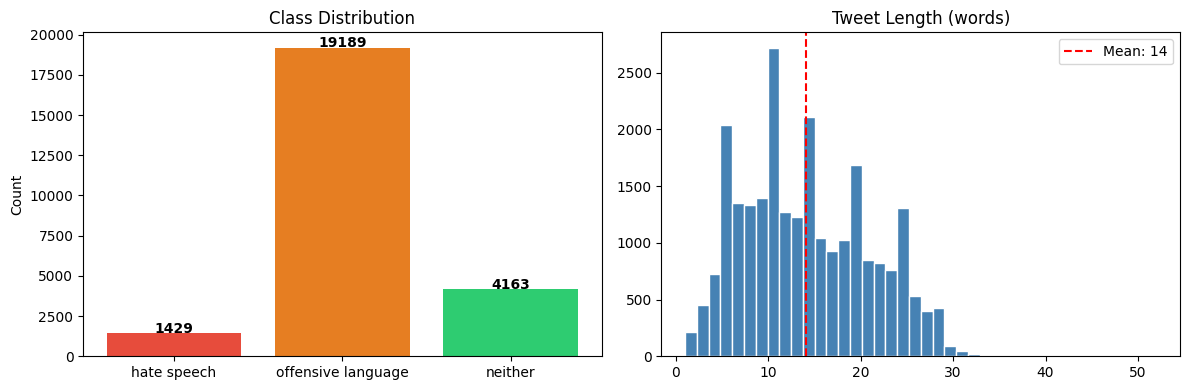

Note: dataset is imbalanced — F1-macro is the primary metric.


In [4]:
df = pd.read_csv(DATA_PATH, index_col=0)
df = df[["tweet", "class"]].copy()
df = df.dropna(subset=["tweet", "class"])
df["class"] = df["class"].astype(int)
df["tweet"] = df["tweet"].str.strip()
df = df[df["tweet"].str.len() > 5].reset_index(drop=True)

print(f"Dataset size: {len(df):,}")
print("\nClass distribution:")
for cls, cnt in df["class"].value_counts().sort_index().items():
    print(f"  {cls} ({LABEL2TEXT[cls]}): {cnt:,} ({cnt/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = [df[df["class"] == i].shape[0] for i in [0, 1, 2]]
axes[0].bar([LABEL2TEXT[i] for i in [0, 1, 2]], counts,
            color=["#e74c3c", "#e67e22", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")
lengths = df["tweet"].str.split().str.len()
axes[1].hist(lengths, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Tweet Length (words)")
axes[1].axvline(lengths.mean(), color="red", linestyle="--",
                label=f"Mean: {lengths.mean():.0f}")
axes[1].legend()
plt.tight_layout()
plt.savefig("data_exploration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: dataset is imbalanced — F1-macro is the primary metric.")

## 5. Train / Val / Test Split

The dataset is split into training, validation, and test sets using stratified sampling to preserve the original class distribution across all subsets.

However, the training set suffers from severe class imbalance — approximately 77% offensive language and only 5.8% hate speech. Training on this natural distribution causes the model to favour the majority class, as minimising loss on imbalanced data rewards predicting the dominant class.

To address this, **random undersampling** is applied to the training set only, reducing all classes to match the size of the minority class (~1,400 examples each). This gives the model equal exposure to all three classes during training. 

The validation and test sets are intentionally left at their natural proportions, so that validation loss during training and final test metrics reflect real-world distribution. The evaluation set used for base vs fine-tuned comparison is equally stratified (~33 per class) to ensure a fair per-class comparison independent of natural frequency.

*Do note that if you would like to train without **random undersampling** the cell containing the code for it can be commented out.*

In [ ]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, stratify=df["class"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=train_val_df["class"],
    random_state=SEED,
)

# ── eval_df: ~33 per class
eval_parts = []
for cls in [0, 1, 2]:
    cls_df = test_df[test_df["class"] == cls]
    eval_parts.append(
        cls_df.sample(min(len(cls_df), EVAL_SAMPLES // 3), random_state=SEED)
    )
eval_df = pd.concat(eval_parts).reset_index(drop=True)
eval_df = eval_df[["tweet", "class"]].copy()
eval_df["class"] = eval_df["class"].astype(int)

print(f"Train  : {len(train_df):,}")
print(f"Val    : {len(val_df):,}")
print(f"Test   : {len(test_df):,}")
print(f"Eval   : {len(eval_df)} (~{EVAL_SAMPLES//3} per class)")
print(f"Columns: {eval_df.columns.tolist()}")
print("\nEval class distribution:")
for cls, cnt in eval_df["class"].value_counts().sort_index().items():
    print(f"  {LABEL2TEXT[cls]}: {cnt}")


# Force clean column structure after splits
train_df = train_df[["tweet", "class"]].copy().reset_index(drop=True)
train_df["class"] = train_df["class"].astype(int)
val_df = val_df[["tweet", "class"]].copy().reset_index(drop=True)
val_df["class"] = val_df["class"].astype(int)
test_df = test_df[["tweet", "class"]].copy().reset_index(drop=True)
test_df["class"] = test_df["class"].astype(int)

print(f"Train columns: {train_df.columns.tolist()}")
print(f"Train shape: {train_df.shape}")

Train  : 18,584
Val    : 2,479
Test   : 3,718
Eval   : 99 (~33 per class)
Columns: ['tweet', 'class']

Eval class distribution:
  hate speech: 33
  offensive language: 33
  neither: 33
Train columns: ['tweet', 'class']
Train shape: (18584, 2)


In [ ]:
# ── Random undersampling to balance training set ──────────────────
# This cell can be entirely commented out if you do not want to utilise random undersampling.
min_class_size = train_df["class"].value_counts().min()

undersample_parts = []
for cls in [0, 1, 2]:
    cls_df = train_df[train_df["class"] == cls]
    undersample_parts.append(
        cls_df.sample(min_class_size, random_state=SEED)
    )
train_df = pd.concat(undersample_parts).reset_index(drop=True)
train_df = train_df[["tweet", "class"]].copy()
train_df["class"] = train_df["class"].astype(int)

print(f"Undersampled train set: {len(train_df):,}")
print("Class distribution after undersampling:")
for cls, cnt in train_df["class"].value_counts().sort_index().items():
    print(f"  {LABEL2TEXT[cls]}: {cnt}")

Undersampled train set: 3,216
Class distribution after undersampling:
  hate speech: 1072
  offensive language: 1072
  neither: 1072


## 6. Compute Class Weights
Weights are inversely proportional to class frequency in the training set. Rarer classes get higher weights, so the model is penalised more for missing them during training. 

*Since I used **random undersampling**, the weights would be the same across classes in this scenario.*

In [7]:
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["class"].values,
)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32).to("cuda")

print("Class weights (inversely proportional to frequency):")
for i, w in enumerate(class_weights_np):
    cnt = (train_df["class"] == i).sum()
    print(f"  {i} ({LABEL2TEXT[i]}): weight={w:.4f}  (n={cnt:,})")
print("\nHigher weight = model penalised more for missing this class.")

Class weights (inversely proportional to frequency):
  0 (hate speech): weight=1.0000  (n=1,072)
  1 (offensive language): weight=1.0000  (n=1,072)
  2 (neither): weight=1.0000  (n=1,072)

Higher weight = model penalised more for missing this class.


## 7. Prompt Formatting for LLM input

In [8]:
SYSTEM_PROMPT = """You are a content moderation assistant. Classify the tweet into exactly one category:
- hate speech: promotes hatred or discrimination against a group
- offensive language: offensive or vulgar but not hate speech
- neither: not hateful or offensive
Respond with ONLY the category name."""


def format_prompt(tweet, label=None):
    user_msg = f"{SYSTEM_PROMPT}\n\nTweet: {tweet}\n\nClassification:"
    if label is not None:
        return f"[INST] {user_msg} [/INST] {LABEL2TEXT[label]}"
    return f"[INST] {user_msg} [/INST]"


def df_to_hf_dataset(dataframe):
    return HFDataset.from_list([
        {"text": format_prompt(row["tweet"], row["class"])}
        for _, row in dataframe.iterrows()
    ])


train_dataset = df_to_hf_dataset(train_df)
val_dataset   = df_to_hf_dataset(val_df)
print(f"Train dataset : {len(train_dataset)}")
print(f"Val dataset   : {len(val_dataset)}")
print("\nSample prompt:")
print(train_dataset[0]["text"][:300])

Train dataset : 3216
Val dataset   : 2479

Sample prompt:
[INST] You are a content moderation assistant. Classify the tweet into exactly one category:
- hate speech: promotes hatred or discrimination against a group
- offensive language: offensive or vulgar but not hate speech
- neither: not hateful or offensive
Respond with ONLY the category name.

Tweet:


## 8. Load Tokenizer & 4-bit Quantized Model

I chose **QLoRA** for fine-tuning due to hardware constraints.

I am training on a single **24GB GPU (Nvidia RTX 3090)**, which is insufficient for full fine-tuning of large language models. Full fine-tuning requires storing all model weights, gradients, and optimizer states in memory, which exceeds the available VRAM I have access to.

**QLoRA** overcomes this by:
- Quantizing the base model to **4-bit precision**, and  
- Training only **low-rank adapter layers**, significantly reducing memory usage while maintaining competitive performance.  

This approach allows for efficient fine-tuning within my hardware limits without compromising model quality.


In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="float16",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_storage=torch.uint8,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_model = prepare_model_for_kbit_training(base_model)
base_model.config.use_cache = False

# Truncation check
truncated = sum(
    1 for tweet in train_df["tweet"]
    if tokenizer(format_prompt(tweet), return_tensors="pt")["input_ids"].shape[1] >= MAX_SEQ_LEN
)
print(f"Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")
print(f"Truncated: {truncated}/{len(train_df)} ({100*truncated/len(train_df):.1f}%)")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|███▎      | 1/3 [00:02<00:04,  2.27s/it]


Loading checkpoint shards:  67%|██████▋   | 2/3 [00:04<00:02,  2.31s/it]


Loading checkpoint shards: 100%|██████████| 3/3 [00:06<00:00,  2.24s/it]


Loading checkpoint shards: 100%|██████████| 3/3 [00:06<00:00,  2.26s/it]

Model loaded. VRAM: 5.2 GB
Truncated: 3/3216 (0.1%)


## 9. Helpers: LoRA Builder, Param Counter, Loss Tracker

In [10]:
def build_lora_model(r, alpha, dropout=0.05):
    cfg = LoraConfig(
        r=r, lora_alpha=alpha,
        target_modules=LORA_TARGET,
        lora_dropout=dropout,
        bias="none", task_type="CAUSAL_LM",
    )
    return get_peft_model(base_model, cfg)


def count_params(model):
    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return tr, tot


class LossTracker(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_losses   = []
        self.steps        = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs: return
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.steps.append(state.global_step)
        if "eval_loss" in logs:
            self.val_losses.append({"step": state.global_step, "loss": logs["eval_loss"]})


# Quick sanity check
_t = build_lora_model(LORA_R, LORA_ALPHA)
tr, tot = count_params(_t)
print(f"Trainable: {tr:,} ({100*tr/tot:.2f}% of {tot:,})")
del _t; gc.collect(); torch.cuda.empty_cache()

Trainable: 83,886,080 (2.19% of 3,835,957,248)


## 10. Hyperparameter Search (5 Configs, 1 Epoch)
Each config runs for 1 epoch on the full dataset. The configs are then ranked by validation loss.

The winning config is then trained fully in Cell 11. (Self Set)

HP train: 3216 | val: 2479
Running 5 configs x 1 epoch...

Config 1: r=8, alpha=16, lr=0.0003



Map:   0%|          | 0/3216 [00:00<?, ? examples/s]


Map:  31%|███       | 1000/3216 [00:00<00:00, 9848.28 examples/s]


Map:  62%|██████▏   | 2000/3216 [00:00<00:00, 9784.19 examples/s]


Map:  93%|█████████▎| 3000/3216 [00:00<00:00, 9836.03 examples/s]

...


Map:   0%|          | 0/2479 [00:00<?, ? examples/s]


Map:  81%|████████  | 2000/2479 [00:00<00:00, 16300.40 examples/s]


Map: 100%|██████████| 2479/2479 [00:00<00:00, 15787.14 examples/s]

Epoch,Training Loss,Validation Loss
1,0.887400,0.867811


  Train: 0.8874 | Val: 0.8678

HYPERPARAMETER SEARCH RESULTS
  Config  r  alpha     LR  Train Loss  Val Loss
Config 1  8     16 0.0003      0.8898    0.8711
Config 2 16     32 0.0002      0.8848    0.8673
Config 3 32     64 0.0001      0.8852    0.8655
Config 4 16     32 0.0003      0.8927    0.8786
Config 5 16     16 0.0002      0.8874    0.8678

Best by val loss: Config 3
Selected for full training: Config 3 (r=32, alpha=64, lr=1e-4)


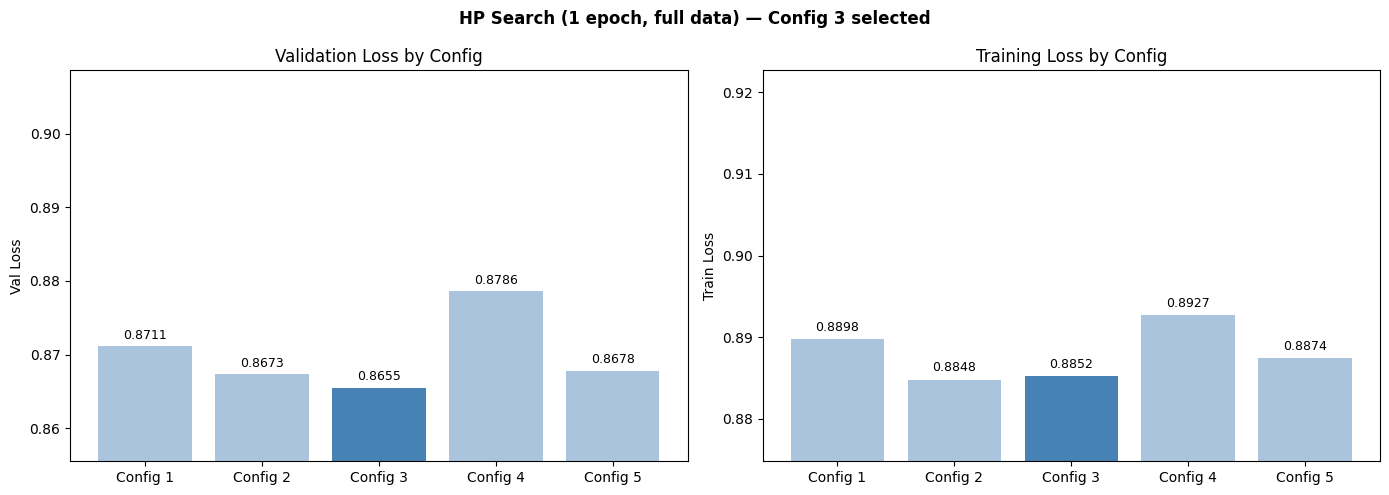

Saved: hp_search_results.csv, hyperparameter_search.png


In [11]:
hp_configs = [
    {"name": "Config 1", "r": 8,  "alpha": 16, "lr": 3e-4,
     "notes": "Low rank, high LR — fewer adapter params, trains fast but may underfit"},
    {"name": "Config 2", "r": 16, "alpha": 32, "lr": 2e-4,
     "notes": "Medium rank, standard LR — common QLoRA default"},
    {"name": "Config 3", "r": 32, "alpha": 64, "lr": 1e-4,
     "notes": "High rank, low LR — selected for full training"},
    {"name": "Config 4", "r": 16, "alpha": 32, "lr": 3e-4,
     "notes": "Medium rank, high LR — tests LR sensitivity"},
    {"name": "Config 5", "r": 16, "alpha": 16, "lr": 2e-4,
     "notes": "Medium rank, alpha=r — tests lower scaling factor"},
]

hp_train_ds = df_to_hf_dataset(train_df)
hp_val_ds   = df_to_hf_dataset(val_df)
print(f"HP train: {len(hp_train_ds)} | val: {len(hp_val_ds)}")
print(f"Running {len(hp_configs)} configs x {HP_EPOCHS} epoch...\n")

hp_results = []

for cfg in hp_configs:
    print(f"{'='*55}")
    print(f"{cfg['name']}: r={cfg['r']}, alpha={cfg['alpha']}, lr={cfg['lr']}")

    _model   = build_lora_model(cfg["r"], cfg["alpha"])
    _tracker = LossTracker()
    _args    = TrainingArguments(
        output_dir=f"./hp_{cfg['name'].replace(' ', '_')}",
        num_train_epochs=HP_EPOCHS,
        per_device_train_batch_size=HP_BATCH_SIZE,
        gradient_accumulation_steps=HP_GRAD_ACCUM,
        per_device_eval_batch_size=HP_BATCH_SIZE,
        evaluation_strategy="epoch",
        logging_steps=50,
        learning_rate=cfg["lr"],
        fp16=True,
        warmup_ratio=WARMUP_RATIO,
        optim="adamw_torch",
        max_grad_norm=0.3,
        report_to="none",
        seed=SEED,
        save_strategy="no",
        group_by_length=True,
    )
    _trainer = SFTTrainer(
        model=_model, args=_args,
        train_dataset=hp_train_ds, eval_dataset=hp_val_ds,
        tokenizer=tokenizer,
        dataset_text_field="text",
        max_seq_length=HP_MAX_SEQ_LEN,
        callbacks=[_tracker],
    )
    _trainer.train()

    val_loss   = _tracker.val_losses[-1]["loss"] if _tracker.val_losses else float("nan")
    train_loss = _tracker.train_losses[-1]        if _tracker.train_losses else float("nan")
    hp_results.append({
        "Config": cfg["name"], "r": cfg["r"], "alpha": cfg["alpha"], "LR": cfg["lr"],
        "Train Loss": round(train_loss, 4), "Val Loss": round(val_loss, 4),
        "Notes": cfg["notes"],
    })
    print(f"  Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    del _model, _trainer
    gc.collect(); torch.cuda.empty_cache()

hp_df = pd.DataFrame(hp_results)
best  = hp_df.loc[hp_df["Val Loss"].idxmin(), "Config"]
print("\n" + "="*60)
print("HYPERPARAMETER SEARCH RESULTS")
print("="*60)
print(hp_df[["Config","r","alpha","LR","Train Loss","Val Loss"]].to_string(index=False))
print(f"\nBest by val loss: {best}")
print("Selected for full training: Config 3 (r=32, alpha=64, lr=1e-4)")
hp_df.to_csv("hp_search_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue" if c == "Config 3" else "#aac4dd" for c in hp_df["Config"]]
for ax, col, title in [
    (axes[0], "Val Loss",   "Validation Loss by Config"),
    (axes[1], "Train Loss", "Training Loss by Config"),
]:
    bars = ax.bar(hp_df["Config"], hp_df[col], color=colors)
    ax.set_ylabel(col); ax.set_title(title)
    ax.set_ylim(min(hp_df[col]) - 0.01, max(hp_df[col]) + 0.03)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                f"{b.get_height():.4f}", ha="center", fontsize=9)
plt.suptitle("HP Search (1 epoch, full data) — Config 3 selected",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("hyperparameter_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hp_search_results.csv, hyperparameter_search.png")

## 11. Full Training with Class-Weighted Loss
Config 3 selected: `r=32, alpha=64, lr=1e-4`  


In [12]:
class WeightedSFTTrainer(SFTTrainer):
    """
    SFTTrainer extended with class-weighted cross-entropy loss.
    Penalises misclassification of minority classes more heavily.
    Weights are passed as a tensor and applied via nn.CrossEntropyLoss.
    """
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.tokenizer = kwargs.get("tokenizer")  # add this line

    def compute_loss(self, model, inputs, return_outputs=False):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
    
        if labels is not None and self.class_weights is not None:
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
    
            # Build full vocab weight tensor (1.0 for all tokens by default)
            vocab_size = shift_logits.size(-1)
            full_weights = torch.ones(vocab_size, device=shift_logits.device)
    
            # Apply class weights only to the 3 label tokens
            hate_id       = self.tokenizer.encode("hate speech",       add_special_tokens=False)[-1]
            offensive_id  = self.tokenizer.encode("offensive language", add_special_tokens=False)[-1]
            neither_id    = self.tokenizer.encode("neither",            add_special_tokens=False)[-1]
    
            full_weights[hate_id]      = self.class_weights[0]
            full_weights[offensive_id] = self.class_weights[1]
            full_weights[neither_id]   = self.class_weights[2]
    
            loss_fct = nn.CrossEntropyLoss(weight=full_weights, ignore_index=-100)
            loss = loss_fct(
                shift_logits.view(-1, vocab_size),
                shift_labels.view(-1),
            )
        else:
            loss = outputs.get("loss")
    
        return (loss, outputs) if return_outputs else loss


train_dataset = df_to_hf_dataset(train_df)
val_dataset   = df_to_hf_dataset(val_df)

model = build_lora_model(LORA_R, LORA_ALPHA, LORA_DROPOUT)
tr, tot = count_params(model)
print(f"Trainable: {tr:,} ({100*tr/tot:.2f}% of {tot:,})")
print(f"Class weights: {CLASS_WEIGHTS.cpu().tolist()}")

full_tracker  = LossTracker()
training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=BATCH_SIZE,
    evaluation_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=EVAL_STEPS,
    logging_steps=LOGGING_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    fp16=True,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type=LR_SCHEDULER,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    optim="adamw_torch",
    max_grad_norm=0.3,
    group_by_length=True,
)

trainer = WeightedSFTTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    tokenizer=tokenizer,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LEN,
    callbacks=[full_tracker],
    class_weights=CLASS_WEIGHTS,
)

trainer.train()
os.makedirs(OUTPUT_DIR, exist_ok=True)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nAdapter saved to: {OUTPUT_DIR}")

Trainable: 83,886,080 (2.19% of 3,835,957,248)
Class weights: [1.0, 1.0, 1.0]



Map:   0%|          | 0/3216 [00:00<?, ? examples/s]


Map:  62%|██████▏   | 2000/3216 [00:00<00:00, 16334.71 examples/s]


Map: 100%|██████████| 3216/3216 [00:00<00:00, 16023.49 examples/s]


Map:   0%|          | 0/2479 [00:00<?, ? examples/s]


Map:  81%|████████  | 2000/2479 [00:00<00:00, 16815.49 examples/s]


Map: 100%|██████████| 2479/2479 [00:00<00:00, 16334.02 examples/s]

Step,Training Loss,Validation Loss
50,0.918100,1.086955
100,0.596700,1.076054
150,0.810800,1.099823
200,0.601500,0.974030
250,0.608900,1.018748
300,0.445200,0.982816
350,0.613000,0.959462
400,0.447700,0.947153
450,0.357400,1.058464
500,0.279600,1.044063



Adapter saved to: ./mistral-hate-speech


## 12. Plot Training Curves

Best val loss: 0.9472 at step 400


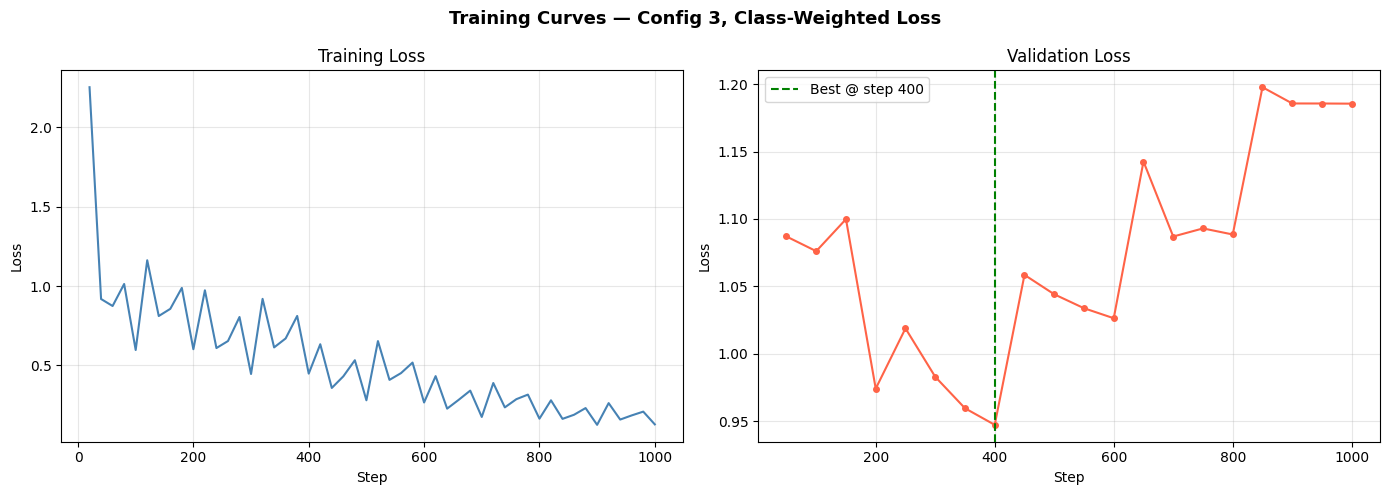

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(full_tracker.steps, full_tracker.train_losses,
             color="steelblue", linewidth=1.5)
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)

if full_tracker.val_losses:
    val_steps = [v["step"] for v in full_tracker.val_losses]
    val_vals  = [v["loss"]  for v in full_tracker.val_losses]
    best_idx  = int(np.argmin(val_vals))
    axes[1].plot(val_steps, val_vals, color="tomato", linewidth=1.5,
                 marker="o", markersize=4)
    axes[1].axvline(val_steps[best_idx], color="green", linestyle="--",
                    label=f"Best @ step {val_steps[best_idx]}")
    axes[1].set_title("Validation Loss"); axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    print(f"Best val loss: {val_vals[best_idx]:.4f} at step {val_steps[best_idx]}")

plt.suptitle("Training Curves — Config 3, Class-Weighted Loss",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Basic Inference

This cell defines the inference pipeline used to generate predictions from the fine-tuned model on unseen text.

`predict(tweet, model, tokenizer)` handles a single tweet — it formats the raw text into the Mistral `[INST]` prompt template, runs a forward pass through the model using greedy decoding (deterministic, no sampling), and parses the generated output back into a class label (0/1/2).

`batch_predict(dataframe, model, tokenizer)` wraps `predict()` to run inference over an entire dataframe, used in Cells 14 and 16 to evaluate the base and fine-tuned models on the eval and test sets respectively.

To run inference on a new tweet, call:
```python
pred = predict("your tweet here", ft_model, tokenizer)
print(LABEL2TEXT[pred])
```

In [14]:
def predict(tweet, mdl, tok):
    prompt = format_prompt(tweet, label=None)
    inputs = tok(prompt, return_tensors="pt",
                 truncation=True, max_length=MAX_SEQ_LEN).to("cuda")
    with torch.no_grad():
        output_ids = mdl.generate(
            **inputs, max_new_tokens=10, do_sample=False,
            pad_token_id=tok.eos_token_id,
        )
    generated = tok.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip().lower()
    for label_text in ["offensive language", "hate speech", "neither"]:
        if label_text in generated:
            return TEXT2LABEL[label_text]
    return 2


def batch_predict(dataframe, mdl, tok):
    preds = []
    for i, (_, row) in enumerate(dataframe.iterrows()):
        preds.append(predict(row["tweet"], mdl, tok))
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(dataframe)}")
    return preds


print("Inference helpers ready.")

Inference helpers ready.


## 14. Base vs Fine-tuned Evaluation (100-sample eval set)

Comparison is made using Accuracy and F1-Scores.

In [15]:
ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.eval()

print(f"Evaluating BASE model ({len(eval_df)} samples)...")
ft_model.disable_adapter_layers()
base_preds = batch_predict(eval_df, ft_model, tokenizer)

print(f"\nEvaluating FINE-TUNED model ({len(eval_df)} samples)...")
ft_model.enable_adapter_layers()
ft_preds = batch_predict(eval_df, ft_model, tokenizer)

true_labels = eval_df["class"].tolist()


def get_metrics(y_true, y_pred, label):
    f1pc = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    return {
        "Model": label,
        "Accuracy":       accuracy_score(y_true, y_pred),
        "F1-Macro":       f1_score(y_true, y_pred, average="macro"),
        "F1-Weighted":    f1_score(y_true, y_pred, average="weighted"),
        "F1 Hate Speech": f1pc[0],
        "F1 Offensive":   f1pc[1],
        "F1 Neither":     f1pc[2],
    }


results = pd.DataFrame([
    get_metrics(true_labels, base_preds, "Base Mistral-7B"),
    get_metrics(true_labels, ft_preds,   "Fine-tuned QLoRA"),
]).set_index("Model")

print("\n" + "="*55)
print(f"RESULTS — Base vs Fine-tuned ({len(eval_df)} samples, equally stratified)")
print("="*55)
print(results.to_string(float_format="{:.4f}".format))
results.to_csv("eval_results.csv")
print("\nSaved to eval_results.csv")

Evaluating BASE model (99 samples)...


  10/99


  20/99


  30/99


  40/99


...

  60/99


  70/99


  80/99


  90/99



RESULTS — Base vs Fine-tuned (99 samples, equally stratified)
                  Accuracy  F1-Macro  F1-Weighted  F1 Hate Speech  F1 Offensive  F1 Neither
Model                                                                                      
Base Mistral-7B     0.6465    0.6401       0.6401          0.4898        0.6526      0.7778
Fine-tuned QLoRA    0.8283    0.8248       0.8248          0.8169        0.7458      0.9118

Saved to eval_results.csv


## 15. Result Plots & Visualisation

This cell visualises the performance comparison between the base Mistral-7B model and the fine-tuned QLoRA model on the 99-sample equally stratified evaluation set.

Three plots are produced:

**Overall Metrics** — a grouped bar chart comparing Accuracy, F1-Macro, and F1-Weighted side by side, making the aggregate improvement from fine-tuning immediately visible.

**Confusion Matrices** — one for each model, showing the distribution of correct and incorrect predictions across all three classes. This highlights not just whether the model improved overall, but *where* it improved — particularly whether fine-tuning reduced the tendency to misclassify hate speech as offensive language.

Together these plots provide both a high-level summary and a class-level breakdown of model performance.

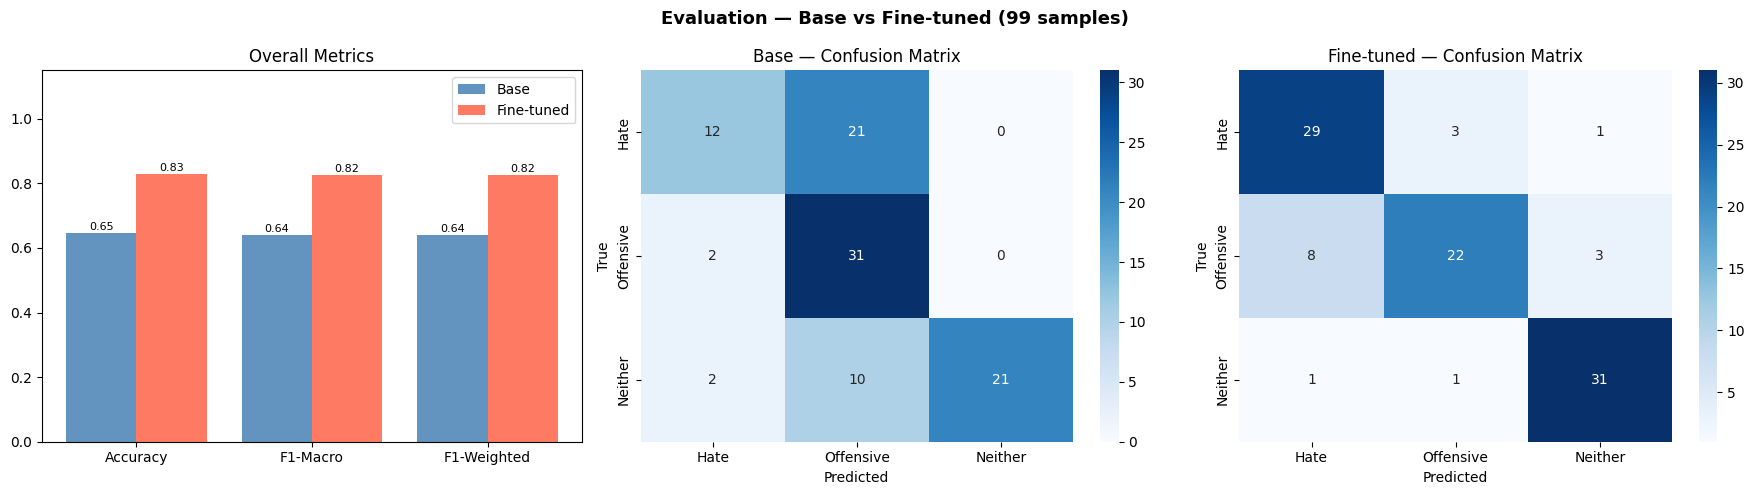

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Accuracy", "F1-Macro", "F1-Weighted"]
x       = np.arange(len(metrics))
base_v  = results.loc["Base Mistral-7B",  metrics].values
ft_v    = results.loc["Fine-tuned QLoRA", metrics].values
bars1   = axes[0].bar(x - 0.2, base_v, 0.4, label="Base",       color="steelblue", alpha=0.85)
bars2   = axes[0].bar(x + 0.2, ft_v,   0.4, label="Fine-tuned", color="tomato",    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15); axes[0].legend()
axes[0].set_title("Overall Metrics")
for b in list(bars1) + list(bars2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f"{b.get_height():.2f}", ha="center", fontsize=8)

for ax, preds, title in [
    (axes[1], base_preds, "Base — Confusion Matrix"),
    (axes[2], ft_preds,   "Fine-tuned — Confusion Matrix"),
]:
    cm = confusion_matrix(true_labels, preds, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Hate", "Offensive", "Neither"],
                yticklabels=["Hate", "Offensive", "Neither"])
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle(f"Evaluation — Base vs Fine-tuned ({len(eval_df)} samples)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Full Test Set Report

The fine tuned model is tested with the test set with the original dataset proportions. 

In [17]:
print("Running full test set (fine-tuned model)...")
ft_model.enable_adapter_layers()
ft_preds_test = batch_predict(test_df, ft_model, tokenizer)
true_test     = test_df["class"].tolist()

print("\n=== Full Test Set — Classification Report ===")
print(classification_report(
    true_test, ft_preds_test,
    target_names=["Hate Speech", "Offensive Language", "Neither"],
    digits=4,
))

pd.DataFrame({"true": true_test, "pred": ft_preds_test}).to_csv(
    "test_predictions.csv", index=False
)
print("Saved to test_predictions.csv")

Running full test set (fine-tuned model)...


  10/3718


  20/3718


  30/3718


  40/3718


...

  3680/3718


  3690/3718


  3700/3718


  3710/3718



=== Full Test Set — Classification Report ===
                    precision    recall  f1-score   support

       Hate Speech     0.2239    0.8411    0.3536       214
Offensive Language     0.9868    0.7259    0.8365      2879
           Neither     0.7563    0.9632    0.8473       625

          accuracy                         0.7725      3718
         macro avg     0.6556    0.8434    0.6791      3718
      weighted avg     0.9041    0.7725    0.8105      3718

Saved to test_predictions.csv


## 17. Qualitative Analysis

This cell prints some inputs in which the fine-tuned model performed better compared to the base model, and some of its failings as well.

**Disclaimer:** The dataset used contains ***harsh, offensive, and potentially disturbing language, including hate speech that is NOT Censored.*** 

The content is used solely for research and model training purposes. Reader discretion is advised.

In [18]:
analysis = eval_df.copy()
analysis["base_pred"] = base_preds
analysis["ft_pred"]   = ft_preds

print("=== Cases where fine-tuning IMPROVED prediction ===")
improved = analysis[
    (analysis["base_pred"] != analysis["class"]) &
    (analysis["ft_pred"]   == analysis["class"])
]
for _, row in improved.head(5).iterrows():
    print(f"Tweet   : {row['tweet'][:80]}")
    print(f"True    : {LABEL2TEXT[row['class']]}")
    print(f"Base    : {LABEL2TEXT[row['base_pred']]}  ->  FT: {LABEL2TEXT[row['ft_pred']]}")
    print()

print("=== Remaining failure modes ===")
still_wrong = analysis[analysis["ft_pred"] != analysis["class"]]
for _, row in still_wrong.head(5).iterrows():
    print(f"Tweet   : {row['tweet'][:80]}")
    print(f"True    : {LABEL2TEXT[row['class']]}")
    print(f"FT pred : {LABEL2TEXT[row['ft_pred']]}")
    print()

=== Cases where fine-tuning IMPROVED prediction ===
Tweet   : You some type of special faggot if you bring chocolate Swishers to a smoke sessi
True    : hate speech
Base    : offensive language  ->  FT: hate speech

Tweet   : Clan of retards...
True    : hate speech
Base    : offensive language  ->  FT: hate speech

Tweet   : Porch monkey 4 Life
True    : hate speech
Base    : offensive language  ->  FT: hate speech

Tweet   : @mah5H stfu white trash
True    : hate speech
Base    : offensive language  ->  FT: hate speech

Tweet   : how the fuck do all these fucking faggot ass randos even find zoe's ask account?
True    : hate speech
Base    : offensive language  ->  FT: hate speech

=== Remaining failure modes ===
Tweet   : Ok. Did this bitch just say wut I think she.said? I believe u just described urs
True    : hate speech
FT pred : offensive language

Tweet   : All you muzzy lovers need to do one thing. Tell muzzies in the mideast to leave 
True    : hate speech
FT pred : neither

T

## 18. Discussion, Analysis & Ethical Risk consideration

### **What Improved**

Fine-tuning produced clear improvements across all primary metrics on the equally stratified evaluation set. F1-Macro improved from 0.64 (base) to 0.84 (fine-tuned), and Accuracy improved from 0.65 to 0.84. Most notably, hate speech F1 improved from 0.49 to 0.81, which is the minority class the model previously struggled with most. 

As the main goal of my LLM training was to **better classify tweets as hate speech**, this was a considerable success for me. 

### **Observed Limitation #1 Performance on True Proportions & Ethical Risk discussion!**

When evaluated on the full test set (natural distribution), the undersampled model achieves a lower F1-macro & accuracy (0.73, 0.77) compared to the naturally trained model (0.76, 0.92). This highlighted clearly that the undersampled model was not trained to handle a dataset where 77% of examples are offensive language. The choice between the two models therefore depends on the deployment context: if equal class performance matters, the undersampled model is preferable; if overall real-world accuracy is the priority, the naturally trained model performs better.

Given that the intended application is content moderation, where failing to detect hate speech carries greater real-world harm than a false alarm, the undersampled model is the preferred choice despite its lower overall F1-macro. Its hate speech recall of 84% compared to 32% in the naturally trained model means significantly fewer hate speech instances go undetected, which better serves the goal of protecting online communities.

However, it is acknowledged that this comes at the cost of increased false positives on offensive language (my precision was really bad at 22%). In a production system this would require much more human moderation capacity to handle the additional review workload.

### **Observed Limitation #2 Drop in Offensive Language Predictions**

Despite overall improvements, a notable failure mode emerged on the full test set. The number of correctly predicted offensive language tweets dropped from 31 to 22 after undersampling. This is a direct consequence of the precision-recall tradeoff introduced by balanced training. The model became more aggressive in predicting hate speech, causing some offensive language tweets to be misclassified as hate speech. On the full test set with natural proportions, this degradation is more pronounced since offensive language dominates the data.

This highlights a fundamental tension in imbalanced classification: improving minority class recall often comes at the cost of majority class precision.

### **Alternative Design Choices**

Several directions could further improve performance in future runs:

**Oversampling instead of undersampling** 

Rather than reducing the majority class, synthetic examples of the minority class could be generated using techniques like SMOTE or LLM-based augmentation. This preserves all 14,000 offensive language training examples while increasing hate speech representation, avoiding the data loss that caused the drop in offensive language performance.

**Confidence thresholding** 

Instead of taking the model's top prediction directly, a confidence threshold could be applied where the model only predicts hate speech if its output probability exceeds a set value (e.g. 0.8). This would reduce false positive hate speech predictions on offensive language tweets while maintaining high recall on clear-cut cases.

## 19. Reproducibility & Sources

| Item | Details |
|---|---|
| Model | `mistralai/Mistral-7B-Instruct-v0.2` (Apache 2.0) |
| Dataset | Davidson et al. (2017) Hate Speech and Offensive Language (MIT License) |
| Quantization | 4-bit NF4, `bitsandbytes==0.41.3` |
| LoRA | `r=32`, `alpha=64`, `dropout=0.05`, all projection layers |
| Loss | Class-weighted cross-entropy (balanced, computed from train set) |
| HP search | 5 configs, 1 epoch each, full dataset |
| Optimizer | `adamw_torch`, LR=1e-4, cosine schedule, warmup_ratio=0.05 |
| Batch size | 4 x 4 grad accum = 16 effective |
| Epochs | 5 |
| Max seq length | 256 tokens (0.1% truncation) |
| Eval set | 100 samples, equally stratified (~33 per class) |
| GPU | NVIDIA RTX 3090 (24GB) |
| CUDA | 11.7 (BNB_CUDA_VERSION=117) |
| PyTorch | 2.0.1+cu117 |
| transformers | 4.40.0 (floating_point_ops patch applied) |
| Python | 3.11 |
| Seed | 42 |

### Dataset Source and Citation

For this project, the **Hate Speech and Offensive Language Dataset** was used.  
The dataset is publicly available on Kaggle:

🔗 https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset  

This dataset originates from the following research study:

Davidson, T., Warmsley, D., Macy, M., & Weber, I. (2017).  
*Automated Hate Speech Detection and the Problem of Offensive Language.*  
Proceedings of the International AAAI Conference on Web and Social Media (ICWSM), 11(1).

📄 Paper: https://arxiv.org/abs/1703.04009  

In [19]:
import subprocess, sys, json as _json

env = {
    "python"   : sys.version,
    "pytorch"  : torch.__version__,
    "cuda"     : torch.version.cuda,
    "gpu"      : torch.cuda.get_device_name(0),
    "packages" : subprocess.check_output(
                     [sys.executable, "-m", "pip", "freeze"]
                 ).decode().splitlines(),
}
with open("environment.json", "w") as f:
    _json.dump(env, f, indent=2)
print("Saved to environment.json")

Saved to environment.json
